In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : Epilepsy Detection from EEG Signals
Algorithm : Gated Recurrent Unit (GRU) – PyTorch
"""
import numpy as np
import torch
from torch.utils.data import TensorDataset,DataLoader,Dataset
import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.signal import butter, filtfilt
import torch.nn as nn
from torch import optim
from scipy.io import loadmat

In [21]:
from IPython.display import clear_output, display
def display_training_progress(train_losses, val_losses, train_accs, val_accs):
    # live update plot each epoch
    clear_output(wait=True)
    fig = plt.figure(figsize=(12,4))
    ax1 = fig.add_subplot(1,2,1)
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.set_title('Loss')

    ax2 = fig.add_subplot(1,2,2)
    ax2.plot(train_accs, label='Train Acc')
    ax2.plot(val_accs, label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.set_title('Accuracy')

    display(fig)
    plt.close(fig)

In [22]:
ds= loadmat('EEG_Segmented.mat')
data= ds['data']
target= ds['target'].squeeze()
print(data.shape)
print(np.unique(target,return_counts=True))
# print(target.shape,target.counts())

(300, 10, 7)
(array([0, 1, 2]), array([100, 100, 100], dtype=int64))


In [23]:
Xtrain, Xtest, ytrain, ytest= train_test_split(data,target, test_size=0.2,
                                                random_state=4)
# scaler= StandardScaler()
# Nsamples, Nfeatures= Xtrain.shape
# Xtrain= scaler.fit_transform(Xtrain.reshape(-1,Nfeatures)).reshape(Nsamples,-1)

In [24]:
# tensor
Xtrain_tensor= torch.tensor(Xtrain,dtype=torch.float32)
ytrain_tensor= torch.tensor(ytrain,dtype=torch.long)
Xtest_tensor= torch.tensor(Xtest,dtype=torch.float32)
ytest_tensor= torch.tensor(ytest,dtype=torch.long)
train_ds= TensorDataset(Xtrain_tensor,ytrain_tensor)
test_ds= TensorDataset(Xtest_tensor,ytest_tensor)


In [25]:
batch_size= 32
train_loader= DataLoader(train_ds,batch_size=batch_size,shuffle=True)
test_loader= DataLoader(test_ds,batch_size=batch_size,shuffle=False)


In [26]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size, 
                 hidden_size, 
                 num_layers,
                 num_classes):
        super(RNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.GRU(input_size, 
                          hidden_size, 
                          num_layers,
                          batch_first=True,
                          bidirectional=True,
                          dropout=0.1 if num_layers>1 else 0.0)
        self.d= int(self.rnn.bidirectional)+1
        self.fc = nn.Linear(hidden_size*self.d, num_classes)

    def forward(self, x,h0=None):
        if h0 is None:
            h_prev = torch.zeros(self.num_layers*self.d, x.size(0), self.hidden_size)
        else: 
            h_prev= h0
        out, ht = self.rnn(x, h_prev)
        if self.rnn.bidirectional:
            h_forward= ht[-2,:,:]
            h_backward= ht[-1,:,:]
            output= torch.cat((h_forward,h_backward),dim=1)
        else:
            output= ht[-1,:,:]
        out = self.fc(output)
        return out

In [27]:
model= RNNClassifier(input_size=7,
                     hidden_size=128,
                     num_layers=2,
                     num_classes=3)
criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(model.parameters(), lr=0.001)


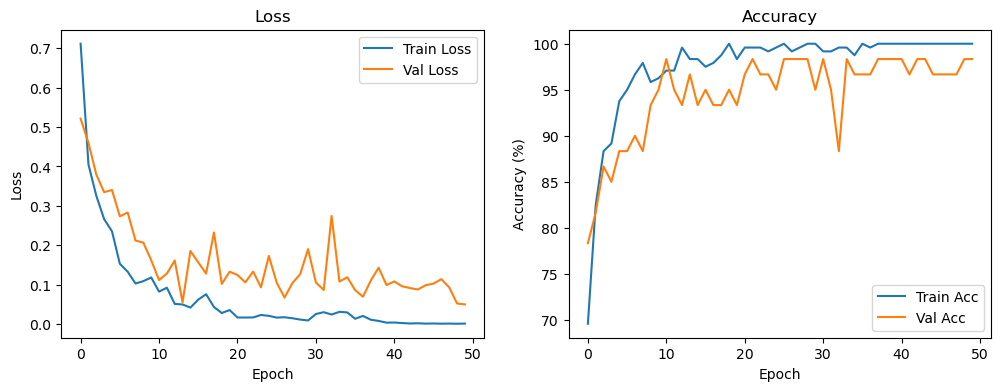

In [28]:

# train and record metrics for plotting
train_losses = []
val_losses = []
train_accs = []
val_accs = []

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss_sum = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        _, preds = torch.max(outputs.data, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = train_loss_sum / len(train_loader)
    train_acc = 100.0 * correct_train / total_train

    # validation
    model.eval()
    val_loss_sum = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item()
            _, preds = torch.max(outputs.data, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = val_loss_sum / len(test_loader)
    val_acc = 100.0 * correct_val / total_val

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    display_training_progress(train_losses, val_losses, train_accs, val_accs)


Test Accuracy: 98.33%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.95      1.00      0.98        21
           2       1.00      0.95      0.97        20

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



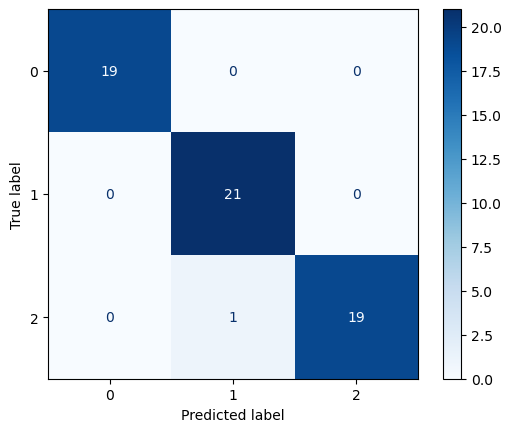

In [29]:
# Evaluation (total accuracy, each class accuracy, confusion matrix plot)
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    y_pred=[]
    y_true=[]
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        y_pred.extend(predicted.numpy())
        y_true.extend(labels.numpy())
    accuracy = 100 * correct / total

    print(f'Test Accuracy: {accuracy:.2f}%')
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
    cm= confusion_matrix(y_true,y_pred)
    disp= ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    print(classification_report(y_true,y_pred))
    plt.show()
    